# Credit Risk — Notebook 02 · Analyse Exploratoire & Sélection Statistique

| | |
|---|---|
| **Auteur** | Abdoulaye Tangara – Quantitative Modeling |
| **Dépendance** | `01_data_engineering.ipynb` (Feature Store) |
| **Statut** | Production-Ready |
| **Référentiel** | SR 11-7 · BCBS 239 · EBA GL/2017/12 |

---

## Objectif

Ce notebook constitue la **validation statistique pré-modélisation**. Il fournit :

1. **Analyse univariée** — distributions, tests de normalité, détection d'outliers, entropie  
2. **Analyse bivariée** — tests d'association robustes (Mann-Whitney, Chi², KS), tailles d'effet  
3. **Weight of Evidence / Information Value** — sélection des variables selon leur pouvoir prédictif  
4. **Analyse des corrélations** — Pearson, Spearman, détection de multicolinéarité (VIF)  
5. **Scorecard de sélection des features** — ranking consolidé pour alimenter le notebook de modélisation

> Toutes les conclusions de ce notebook doivent être documentées dans le **Model Documentation Report** avant toute mise en production (exigence SR 11-7).

---

## 0 · Environnement

In [ ]:
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import (
    chi2_contingency, mannwhitneyu, kstest, normaltest,
    levene, pointbiserialr, spearmanr
)
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns

from google.colab import drive

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger(__name__)

# Palette Morgan Stanley
MS_BLUE  = '#003087'; MS_LIGHT = '#6699CC'; MS_GREY = '#666666'
MS_RED   = '#CC0000'; MS_GREEN = '#006633'; MS_AMBER = '#CC8800'
MS_PALETTE = [MS_BLUE, MS_RED, MS_AMBER, MS_GREEN, MS_LIGHT, MS_GREY]

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#CCCCCC', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EEEEEE', 'grid.linewidth': 0.5,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'legend.frameon': False,
})

drive.mount('/content/drive', force_remount=True)
BASE_PATH    = Path('/content/drive/MyDrive/Credit_Risk_PD_LGD_EAD')
INTERIM_PATH = BASE_PATH / 'DATA' / 'INTERIM'
REPORTS_PATH = BASE_PATH / 'REPORTS'
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


## 1 · Chargement des Données

In [ ]:
# Charger depuis le Feature Store du Notebook 01
df = pd.read_csv(INTERIM_PATH / 'loan_cleaned.csv', low_memory=False)

TARGET = 'target_default'

# Identifier les blocs de variables
num_vars = [
    c for c in df.select_dtypes(include='number').columns
    if c != TARGET and not c.startswith('fe_missing') and not c.startswith('fe_outlier')
    and c not in ['target_default']
]
cat_vars = [
    c for c in df.select_dtypes(include=['category', 'object']).columns
    if c not in ['loan_status']
]

log.info('Dataset chargé : %d obs × %d cols | Taux défaut : %.2f%%',
         *df.shape, df[TARGET].mean() * 100)

## 2 · Analyse Univariée

In [ ]:
# =============================================================================
# 2.1 STATISTIQUES DESCRIPTIVES — Variables numériques
# =============================================================================
def univariate_numeric(df: pd.DataFrame, num_vars: list, target: str) -> pd.DataFrame:
    """
    Rapport statistique univarié pour toutes les variables numériques.
    Inclut : percentiles P1/P99, skewness, kurtosis, normalité, outliers.
    """
    rows = []
    for var in num_vars:
        if var not in df.columns:
            continue
        data = df[var].dropna()
        if len(data) < 100:
            continue

        # Percentiles
        p = np.percentile(data, [1, 5, 25, 50, 75, 95, 99])

        # Moments
        skew = stats.skew(data)
        kurt = stats.kurtosis(data)

        # Test de normalité (D'Agostino-Pearson, robuste pour n > 20)
        _, p_norm = normaltest(data) if len(data) >= 20 else (None, 1)

        # Outliers IQR
        Q1, Q3 = p[2], p[4]
        IQR = Q3 - Q1
        n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()

        # Test Levene (homogénéité variance entre default/non-default)
        g0 = df[df[target]==0][var].dropna()
        g1 = df[df[target]==1][var].dropna()
        p_levene = levene(g0, g1).pvalue if (len(g0) > 10 and len(g1) > 10) else np.nan

        rows.append({
            'variable'   : var,
            'n'          : len(data),
            'mean'       : data.mean(),
            'std'        : data.std(),
            'p1'         : p[0], 'p5': p[1], 'p25': p[2],
            'median'     : p[3],
            'p75'        : p[4], 'p95': p[5], 'p99': p[6],
            'skewness'   : skew,
            'kurtosis'   : kurt,
            'p_normal'   : p_norm,
            'is_normal'  : p_norm > 0.05,
            'n_outliers_iqr': n_outliers,
            'pct_outliers'  : n_outliers / len(data),
            'p_levene'   : p_levene,
            'var_homog'  : p_levene > 0.05 if not np.isnan(p_levene) else None,
        })

    return pd.DataFrame(rows).set_index('variable')


uv_num = univariate_numeric(df, num_vars, TARGET)
display(uv_num[['mean', 'std', 'median', 'skewness', 'kurtosis', 'is_normal', 'pct_outliers']].round(4))

,mean,std,median,skewness,kurtosis,is_normal,pct_outliers
variable,,,,,,,
loan_amnt,15046.9312,9190.2455,12900.0000,0.7778,-0.1194,False,0.0156
funded_amnt,15041.6641,9188.4130,12875.0000,0.7788,-0.1170,False,0.0156
funded_amnt_inv,15023.4376,9192.3318,12800.0000,0.7783,-0.1167,False,0.0156
int_rate,13.0929,4.8321,12.6200,0.7681,0.5940,False,0.0182
installment,445.8071,267.1711,377.9900,1.0017,0.6892,False,0.0293
...,...,...,...,...,...,...,...
fe_revol_burden,0.2177,0.1645,0.1799,1.3507,2.1018,False,0.0379
fe_delinquency_ratio,0.0000,0.0000,0.0000,NaN,NaN,False,0.0000
fe_inq_per_account,0.0490,0.0782,0.0000,1.9039,3.6744,False,0.0511


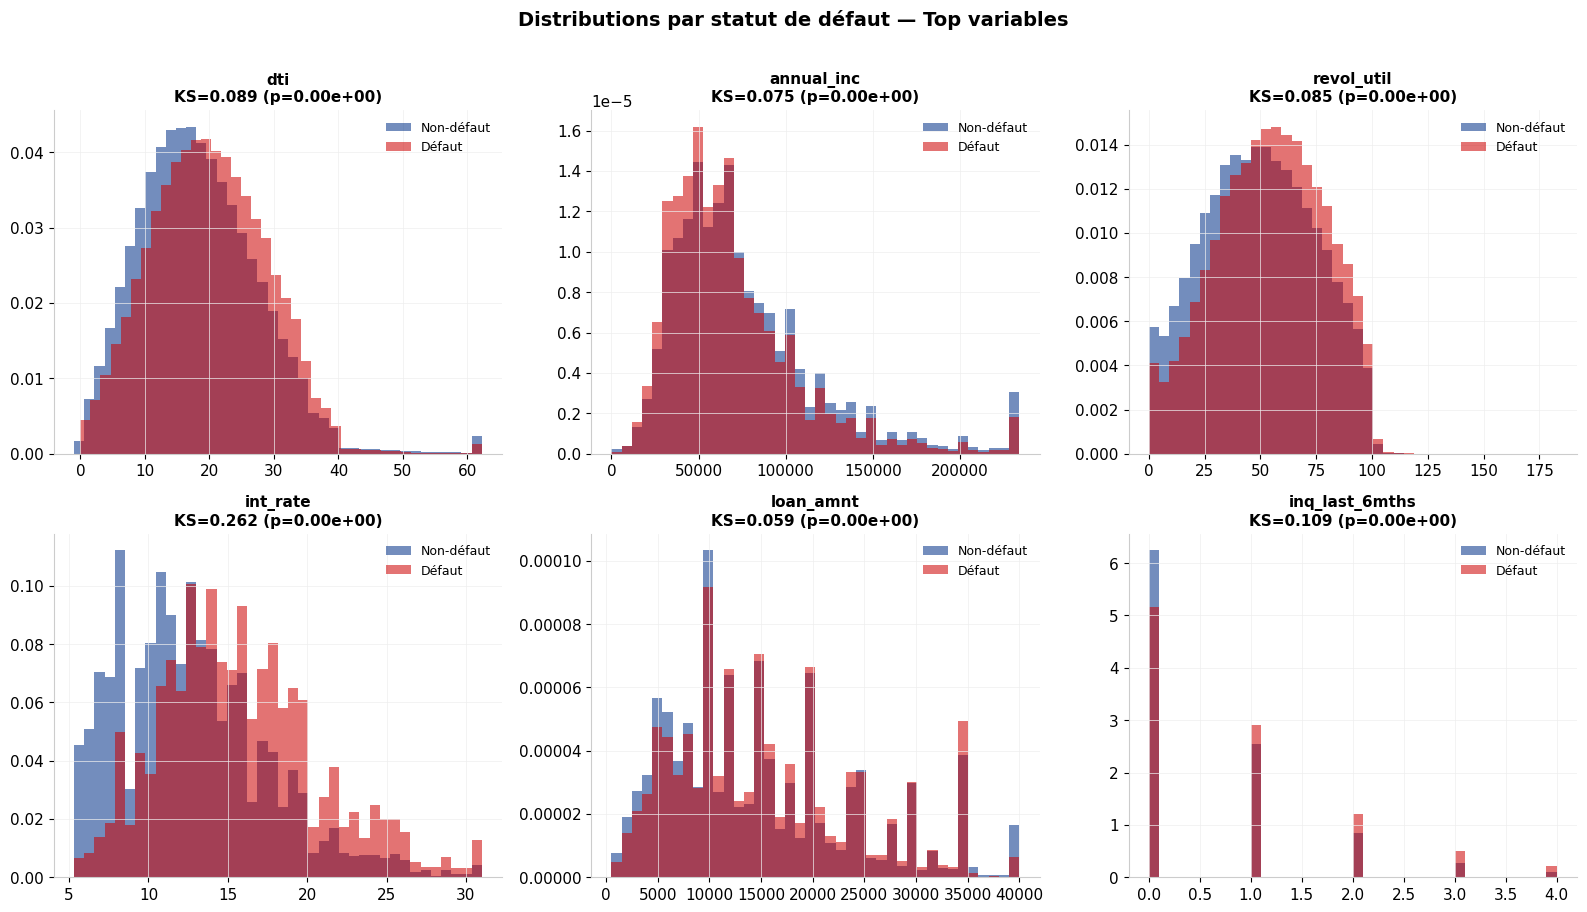

In [ ]:
# =============================================================================
# 2.2 VISUALISATION — Top 6 variables numériques (distribution par classe)
# =============================================================================
TOP_VARS = ['dti', 'annual_inc', 'revol_util', 'int_rate', 'loan_amnt', 'inq_last_6mths']
TOP_VARS = [v for v in TOP_VARS if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, var in zip(axes.flatten(), TOP_VARS):
    g0 = df[df[TARGET] == 0][var].dropna()
    g1 = df[df[TARGET] == 1][var].dropna()

    ax.hist(g0, bins=40, density=True, alpha=0.55, color=MS_BLUE,  label='Non-défaut')
    ax.hist(g1, bins=40, density=True, alpha=0.55, color=MS_RED,   label='Défaut')

    # KS stat en annotation
    ks_stat, ks_p = kstest(g0, g1)
    ax.set_title(f'{var}\nKS={ks_stat:.3f} (p={ks_p:.2e})', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Distributions par statut de défaut — Top variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# 2.3 VARIABLES CATÉGORIELLES — Entropie & taux de défaut par modalité
# =============================================================================
def univariate_categorical(df: pd.DataFrame, cat_vars: list, target: str) -> pd.DataFrame:
    """Calcule entropie, taux de défaut par modalité et test Chi² d'uniformité."""
    rows = []
    for var in cat_vars:
        if var not in df.columns:
            continue
        freq = df[var].value_counts(normalize=True)
        n_cat = df[var].nunique()

        # Entropie de Shannon normalisée
        entropy     = -(freq * np.log(freq + 1e-10)).sum()
        max_entropy = np.log(n_cat) if n_cat > 1 else 1
        entropy_r   = entropy / max_entropy

        # Taux de défaut min / max par modalité
        dr_by_cat = df.groupby(var, observed=True)[target].mean()
        dr_range  = dr_by_cat.max() - dr_by_cat.min()

        # Chi² vs cible
        contingency = pd.crosstab(df[var], df[target])
        if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
            chi2, p_chi2, dof, _ = chi2_contingency(contingency)
            n = contingency.sum().sum()
            cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1))) if n > 0 else 0
        else:
            chi2, p_chi2, cramers_v = np.nan, np.nan, np.nan

        rows.append({
            'variable'   : var,
            'n_categories': n_cat,
            'entropy_norm': entropy_r,
            'dominant_pct': freq.iloc[0],
            'dr_range'   : dr_range,
            'chi2'       : chi2,
            'p_chi2'     : p_chi2,
            'cramers_v'  : cramers_v,
            'significant': p_chi2 < 0.05 if not np.isnan(p_chi2) else False,
        })

    return pd.DataFrame(rows).set_index('variable').sort_values('cramers_v', ascending=False)


uv_cat = univariate_categorical(df, cat_vars, TARGET)
display(uv_cat[['n_categories', 'entropy_norm', 'cramers_v', 'dr_range', 'significant']].round(4))

,n_categories,entropy_norm,cramers_v,dr_range,significant
variable,,,,,
last_credit_pull_d,140,0.4093,0.4129,0.7638,True
debt_settlement_flag,2,0.1101,0.3207,0.8858,True
last_pymnt_d,135,0.6268,0.3160,0.7351,True
sub_grade,35,0.8959,0.2324,0.3957,True
grade,7,0.8140,0.2283,0.3605,True
title,63154,0.2025,0.1917,1.0000,True
issue_d,139,0.8783,0.1838,0.3223,True
verification_status,3,0.9912,0.0950,0.0805,True
term,2,0.8660,0.0878,0.0643,True


## 3 · Weight of Evidence & Information Value

In [ ]:
# =============================================================================
# 3.1 WoE / IV — Standard industrie bancaire pour la sélection de variables
#
# IV < 0.02  : Non prédictif
# 0.02–0.10  : Faiblement prédictif
# 0.10–0.30  : Modérément prédictif
# 0.30–0.50  : Fortement prédictif
# > 0.50     : Suspect (vérifier leakage)
# =============================================================================
def compute_woe_iv(df: pd.DataFrame, feature: str, target: str,
                   n_bins: int = 10) -> tuple:
    """
    Calcule le Weight of Evidence et l'Information Value pour une feature.
    Pour les variables numériques : discrétisation par quantiles.
    Pour les variables catégorielles : utilisation des modalités directement.
    """
    df_ = df[[feature, target]].dropna().copy()
    n_total = len(df_)
    n_events    = df_[target].sum()
    n_nonevents = n_total - n_events

    if n_events == 0 or n_nonevents == 0:
        return None, 0.0

    # Discrétisation si numérique
    if pd.api.types.is_numeric_dtype(df_[feature]):
        try:
            df_['bin'] = pd.qcut(df_[feature], n_bins, duplicates='drop')
        except Exception:
            df_['bin'] = pd.cut(df_[feature], n_bins)
    else:
        df_['bin'] = df_[feature]

    grouped = df_.groupby('bin', observed=True)[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']

    # WoE et IV — formule standard
    eps = 0.5  # correction de continuité
    grouped['dist_events']    = (grouped['events']     + eps) / (n_events     + eps)
    grouped['dist_nonevents'] = (grouped['non_events'] + eps) / (n_nonevents  + eps)
    grouped['woe'] = np.log(grouped['dist_events'] / grouped['dist_nonevents'])
    grouped['iv']  = (grouped['dist_events'] - grouped['dist_nonevents']) * grouped['woe']

    iv_total = grouped['iv'].sum()
    return grouped, iv_total


def iv_classification(iv: float) -> str:
    if iv < 0.02:  return 'Non prédictif'
    if iv < 0.10:  return 'Faible'
    if iv < 0.30:  return 'Modéré'
    if iv < 0.50:  return 'Fort'
    return '⚠ Suspect (leakage?)'


# Calcul sur toutes les variables numériques
ANALYSIS_VARS = [c for c in num_vars + cat_vars if c in df.columns and c != TARGET]

iv_results = []
for var in ANALYSIS_VARS:
    _, iv = compute_woe_iv(df, var, TARGET)
    iv_results.append({'feature': var, 'iv': iv, 'classe': iv_classification(iv)})

iv_df = pd.DataFrame(iv_results).sort_values('iv', ascending=False).set_index('feature')
print(f'Variables avec IV > 0.10 (modérément prédictives) : {(iv_df["iv"] > 0.10).sum()}')
display(iv_df.head(25))

Variables avec IV > 0.10 (modérément prédictives) : 16


,iv,classe
feature,,
last_pymnt_amnt,1.729827,⚠ Suspect (leakage?)
last_pymnt_d,1.696558,⚠ Suspect (leakage?)
last_credit_pull_d,1.072547,⚠ Suspect (leakage?)
debt_settlement_flag,1.006551,⚠ Suspect (leakage?)
out_prncp,0.858582,⚠ Suspect (leakage?)
out_prncp_inv,0.858558,⚠ Suspect (leakage?)
total_rec_prncp,0.757012,⚠ Suspect (leakage?)
issue_d,0.559189,⚠ Suspect (leakage?)
sub_grade,0.518823,⚠ Suspect (leakage?)


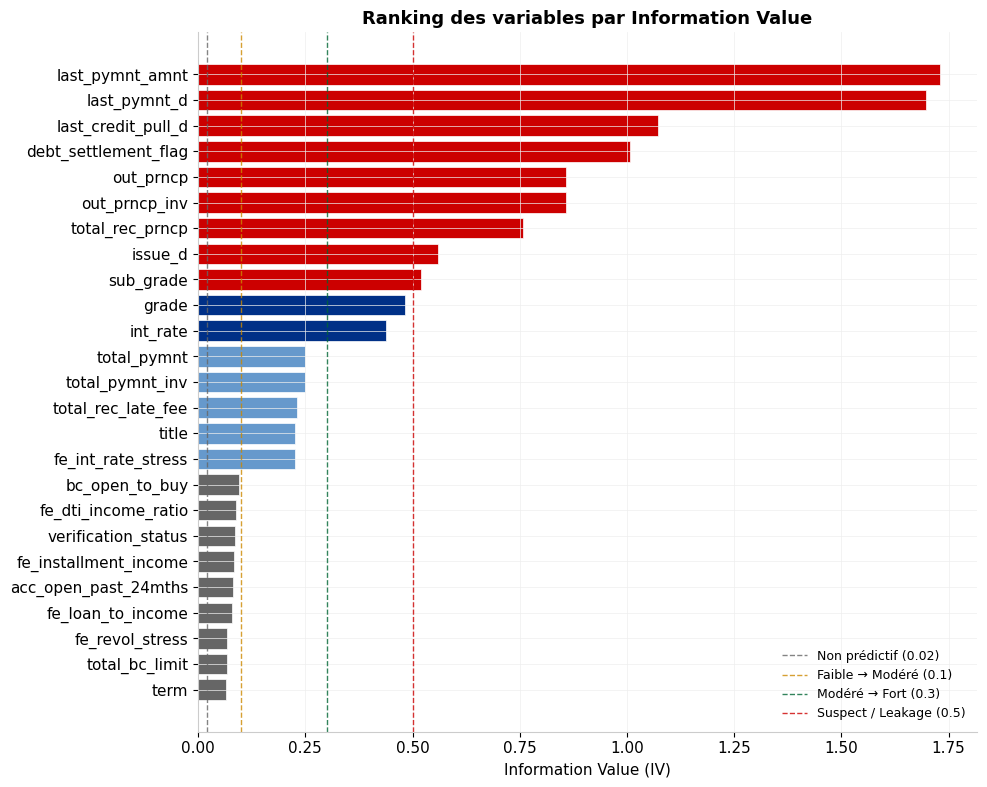

In [ ]:
# =============================================================================
# 3.2 VISUALISATION — Barplot IV avec seuils réglementaires
# =============================================================================
top_iv = iv_df[iv_df['iv'] > 0.02].head(25).sort_values('iv')

fig, ax = plt.subplots(figsize=(10, 8))

colors = [MS_RED if v > 0.5 else MS_BLUE if v > 0.30 else MS_LIGHT if v > 0.10 else MS_GREY
          for v in top_iv['iv']]
ax.barh(top_iv.index, top_iv['iv'], color=colors, edgecolor='white', linewidth=0.5)

# Lignes de seuil
for threshold, label, color in [(0.02, 'Non prédictif', MS_GREY),
                                 (0.10, 'Faible → Modéré', MS_AMBER),
                                 (0.30, 'Modéré → Fort',   MS_GREEN),
                                 (0.50, 'Suspect / Leakage', MS_RED)]:
    ax.axvline(threshold, color=color, linestyle='--', linewidth=1, alpha=0.8, label=f'{label} ({threshold})')

ax.set_xlabel('Information Value (IV)')
ax.set_title('Ranking des variables par Information Value')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_iv_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Analyse Bivariée Robuste

In [ ]:
# =============================================================================
# 4.1 TESTS D'ASSOCIATION — Variables numériques vs cible binaire
#
# Stratégie adaptative :
# - Distribution normale → T-test de Welch + Cohen's d
# - Distribution non-normale → Mann-Whitney U + Rank-Biserial r
# =============================================================================
def bivariate_num_analysis(df: pd.DataFrame, num_vars: list, target: str) -> pd.DataFrame:
    rows = []
    for var in num_vars:
        if var not in df.columns:
            continue
        g0 = df[df[target] == 0][var].dropna()
        g1 = df[df[target] == 1][var].dropna()

        if len(g0) < 30 or len(g1) < 30:
            continue

        # Test de normalité
        _, p0 = normaltest(g0) if len(g0) >= 20 else (None, 0)
        _, p1 = normaltest(g1) if len(g1) >= 20 else (None, 0)
        is_normal = (p0 > 0.05 and p1 > 0.05)

        if is_normal:
            stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)  # Welch
            test = "T-test Welch"
            # Cohen's d
            pooled = np.sqrt(((len(g0)-1)*g0.std()**2 + (len(g1)-1)*g1.std()**2) /
                             (len(g0)+len(g1)-2))
            effect = (g1.mean() - g0.mean()) / pooled if pooled > 0 else 0
            effect_name = "Cohen's d"
        else:
            stat, p_val = mannwhitneyu(g0, g1, alternative='two-sided')
            test = "Mann-Whitney U"
            # Rank-Biserial Correlation
            n_pairs = len(g0) * len(g1)
            effect = 1 - (2 * stat) / n_pairs
            effect_name = "Rank-Biserial r"

        # KS statistic — séparation des distributions
        ks_stat, ks_p = kstest(g0, g1)

        rows.append({
            'variable'    : var,
            'test'        : test,
            'stat'        : stat,
            'p_value'     : p_val,
            'significant' : p_val < 0.05,
            'effect_type' : effect_name,
            'effect_size' : abs(effect),
            'ks_stat'     : ks_stat,
            'ks_p'        : ks_p,
            'mean_default': g1.mean(),
            'mean_nondefault': g0.mean(),
            'delta_mean_pct': (g1.mean() - g0.mean()) / (g0.mean() + 1e-9),
        })

    return (pd.DataFrame(rows)
            .set_index('variable')
            .sort_values('effect_size', ascending=False))


biv_num = bivariate_num_analysis(df, num_vars, TARGET)
sig_vars = biv_num[biv_num['significant']].index.tolist()
print(f'Variables numériques significativement associées au défaut : {len(sig_vars)} / {len(biv_num)}')
display(biv_num[['test', 'p_value', 'effect_size', 'ks_stat', 'delta_mean_pct']].round(4))

Variables numériques significativement associées au défaut : 67 / 75


,test,p_value,effect_size,ks_stat,delta_mean_pct
variable,,,,,
total_rec_prncp,Mann-Whitney U,0.0,0.4256,0.3430,-0.5547
out_prncp_inv,Mann-Whitney U,0.0,0.3899,0.3919,-0.8257
out_prncp,Mann-Whitney U,0.0,0.3899,0.3919,-0.8253
int_rate,Mann-Whitney U,0.0,0.3563,0.2623,0.2353
last_pymnt_amnt,Mann-Whitney U,0.0,0.3457,0.3487,-0.8743
...,...,...,...,...,...
policy_code,Mann-Whitney U,1.0,0.0000,0.0000,0.0000
pub_rec,Mann-Whitney U,1.0,0.0000,0.0000,0.0000
recoveries,Mann-Whitney U,1.0,0.0000,0.0000,0.0000


In [ ]:
# =============================================================================
# 4.2 TESTS D'ASSOCIATION — Variables catégorielles vs cible
# =============================================================================
def bivariate_cat_analysis(df: pd.DataFrame, cat_vars: list, target: str) -> pd.DataFrame:
    rows = []
    for var in cat_vars:
        if var not in df.columns:
            continue
        contingency = pd.crosstab(df[var], df[target])
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue

        chi2, p_val, dof, expected = chi2_contingency(contingency)
        n = contingency.sum().sum()
        min_dim = min(contingency.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 and n > 0 else 0

        rows.append({
            'variable'   : var,
            'n_categories': df[var].nunique(),
            'chi2'       : chi2,
            'p_value'    : p_val,
            'dof'        : dof,
            "cramers_v"  : cramers_v,
            'significant': p_val < 0.05,
        })

    return (pd.DataFrame(rows)
            .set_index('variable')
            .sort_values('cramers_v', ascending=False))


biv_cat = bivariate_cat_analysis(df, cat_vars, TARGET)
print(f'Variables catégorielles significatives : {biv_cat["significant"].sum()} / {len(biv_cat)}')
display(biv_cat[['n_categories', 'chi2', 'p_value', 'cramers_v', 'significant']].round(4))

Variables catégorielles significatives : 19 / 19


,n_categories,chi2,p_value,cramers_v,significant
variable,,,,,
last_credit_pull_d,140,385462.1694,0.0,0.4129,True
debt_settlement_flag,2,232446.5239,0.0,0.3207,True
last_pymnt_d,135,225721.2477,0.0,0.3160,True
sub_grade,35,122147.0268,0.0,0.2324,True
grade,7,117793.1639,0.0,0.2283,True
title,63154,83082.2544,0.0,0.1917,True
issue_d,139,76374.6136,0.0,0.1838,True
verification_status,3,20399.2394,0.0,0.0950,True
term,2,17424.7972,0.0,0.0878,True


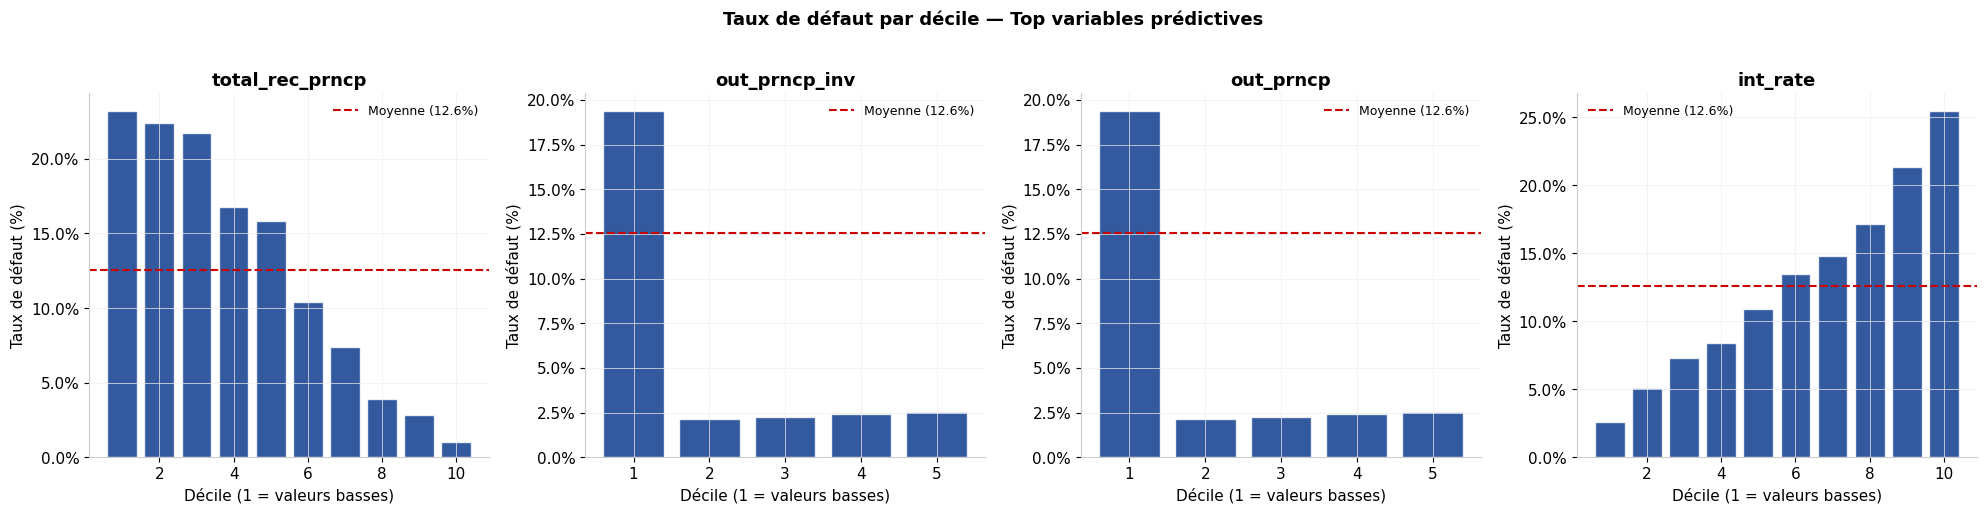

In [ ]:
# =============================================================================
# 4.3 ANALYSE DU TAUX DE DÉFAUT PAR DÉCILE — Top variables prédictives
# =============================================================================
top_predictors = biv_num.sort_values('effect_size', ascending=False).head(4).index.tolist()
top_predictors = [v for v in top_predictors if v in df.columns]

fig, axes = plt.subplots(1, len(top_predictors), figsize=(5*len(top_predictors), 5))
if len(top_predictors) == 1:
    axes = [axes]

for ax, var in zip(axes, top_predictors):
    temp = df[[var, TARGET]].copy()
    try:
        temp['decile'] = pd.qcut(temp[var], 10, labels=False, duplicates='drop')
    except Exception:
        temp['decile'] = pd.cut(temp[var], 10, labels=False)

    dr_decile = temp.groupby('decile')[TARGET].mean() * 100

    ax.bar(dr_decile.index + 1, dr_decile.values, color=MS_BLUE, alpha=0.8, edgecolor='white')
    ax.axhline(df[TARGET].mean() * 100, color=MS_RED, linestyle='--', linewidth=1.5,
               label=f'Moyenne ({df[TARGET].mean():.1%})')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Décile (1 = valeurs basses)')
    ax.set_ylabel('Taux de défaut (%)')
    ax.set_title(f'{var}')
    ax.legend(fontsize=9)

plt.suptitle('Taux de défaut par décile — Top variables prédictives', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_default_rate_decile.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Corrélations & Multicolinéarité

Paires hautement corrélées (|r| > 0.70) : 11


,var1,var2,pearson_r,spearman_r
0,loan_amnt,funded_amnt,0.999755,0.999776
8,total_pymnt,total_pymnt_inv,0.999359,0.998942
3,funded_amnt,funded_amnt_inv,0.999341,0.998914
1,loan_amnt,funded_amnt_inv,0.999038,0.998614
7,out_prncp,out_prncp_inv,0.993677,0.999988
9,total_pymnt,total_rec_prncp,0.967222,0.967576
10,total_pymnt_inv,total_rec_prncp,0.966391,0.966408
4,funded_amnt,installment,0.945972,0.964759
2,loan_amnt,installment,0.945630,0.964412
5,funded_amnt_inv,installment,0.945123,0.963309


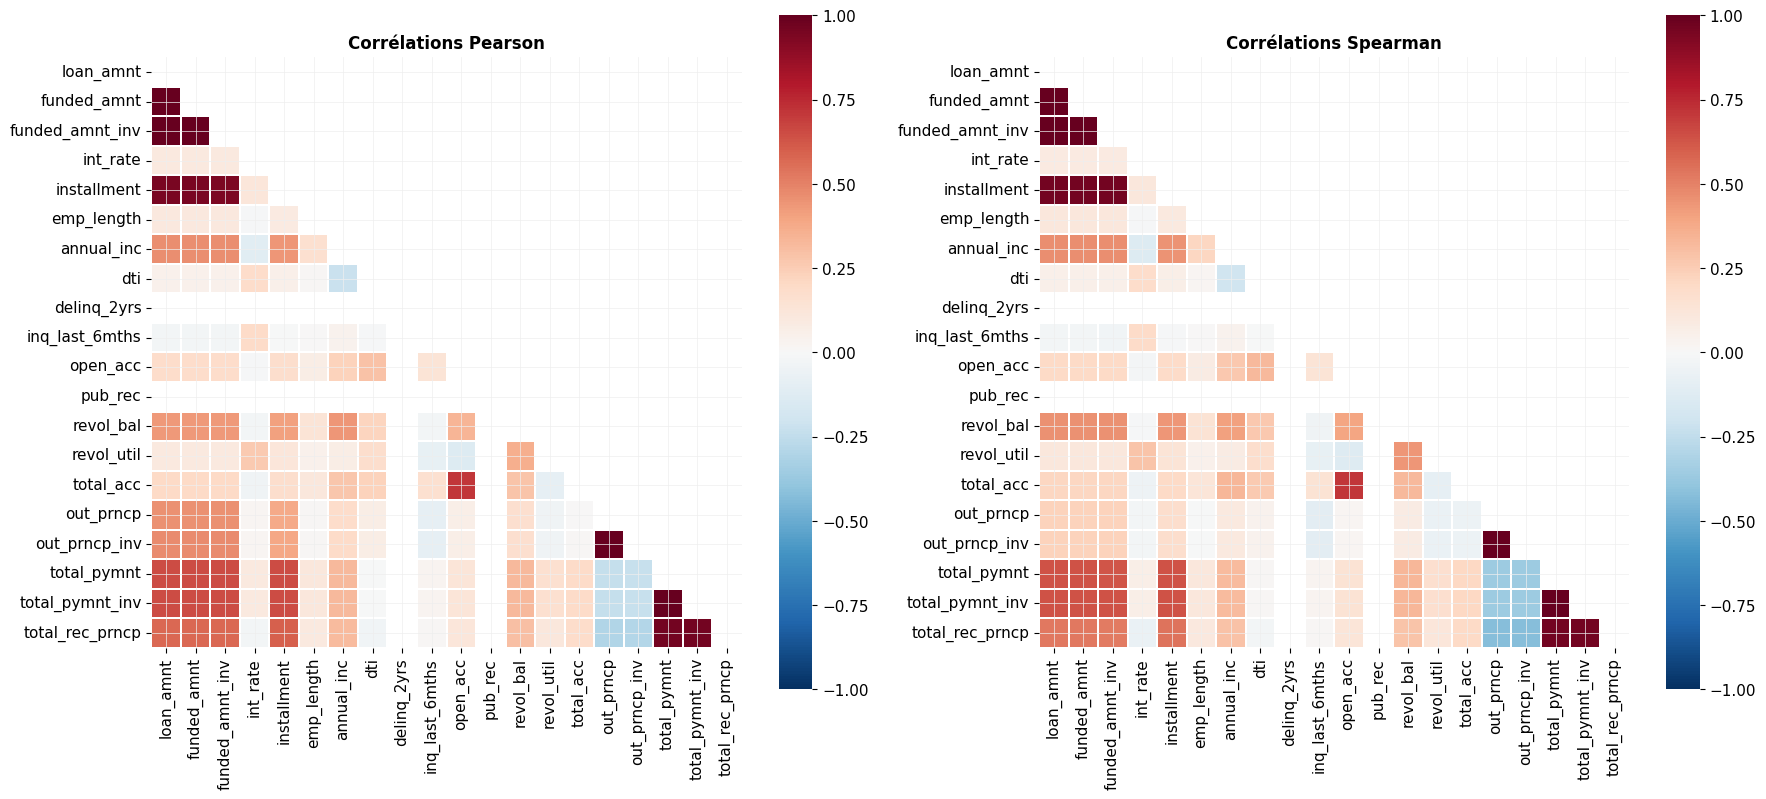

In [ ]:
# =============================================================================
# 5.1 MATRICE DE CORRÉLATION — Pearson & Spearman
# =============================================================================
CORR_VARS = [v for v in num_vars if v in df.columns][:20]  # Limiter pour lisibilité

pearson_m  = df[CORR_VARS].corr(method='pearson')
spearman_m = df[CORR_VARS].corr(method='spearman')

# Paires hautement corrélées
high_corr = []
for i in range(len(pearson_m.columns)):
    for j in range(i+1, len(pearson_m.columns)):
        r = abs(pearson_m.iloc[i, j])
        if r > 0.70:
            high_corr.append({
                'var1': pearson_m.columns[i],
                'var2': pearson_m.columns[j],
                'pearson_r': pearson_m.iloc[i, j],
                'spearman_r': spearman_m.iloc[i, j],
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('pearson_r', key=abs, ascending=False)
print(f'Paires hautement corrélées (|r| > 0.70) : {len(high_corr_df)}')
if len(high_corr_df) > 0:
    display(high_corr_df)

# Heatmap
mask = np.triu(np.ones_like(pearson_m, dtype=bool))
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, matrix, title in zip(axes, [pearson_m, spearman_m], ['Pearson', 'Spearman']):
    sns.heatmap(matrix, mask=mask, annot=len(CORR_VARS) <= 15, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.3, ax=ax,
                annot_kws={'size': 8})
    ax.set_title(f'Corrélations {title}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# 5.2 VARIANCE INFLATION FACTOR (VIF) — Détection de multicolinéarité
#
# VIF > 10 → multicolinéarité sévère → variable à supprimer ou combiner
# VIF 5–10 → multicolinéarité modérée → surveillance requise
# VIF < 5  → acceptable
# =============================================================================
from sklearn.preprocessing import StandardScaler

# Filtrer les variables numériques continues (pas de binaires)
vif_vars = [
    v for v in num_vars
    if v in df.columns and df[v].nunique() > 10
][:20]

X_vif = df[vif_vars].dropna()
X_vif_scaled = StandardScaler().fit_transform(X_vif)

vif_data = pd.DataFrame({
    'feature': vif_vars,
    'VIF': [variance_inflation_factor(X_vif_scaled, i) for i in range(len(vif_vars))]
}).sort_values('VIF', ascending=False)

vif_data['flag'] = vif_data['VIF'].apply(
    lambda v: '⛔ Sévère' if v > 10 else '⚠ Modéré' if v > 5 else '✓ OK'
)

display(vif_data)

,feature,VIF,flag
1,funded_amnt,5973.579704,⛔ Sévère
14,total_pymnt,4150.199822,⛔ Sévère
15,total_pymnt_inv,3882.548171,⛔ Sévère
2,funded_amnt_inv,3776.531069,⛔ Sévère
0,loan_amnt,2057.417209,⛔ Sévère
16,total_rec_prncp,92.700120,⛔ Sévère
13,out_prncp_inv,89.938965,⛔ Sévère
12,out_prncp,84.076147,⛔ Sévère
17,total_rec_int,13.921714,⛔ Sévère
4,installment,12.782143,⛔ Sévère


## 6 · Scorecard de Sélection des Features

In [ ]:
# =============================================================================
# 6.1 SCORECARD CONSOLIDÉE
# Combine IV, taille d'effet bivariée, et VIF pour un ranking final.
# =============================================================================
scorecard = pd.DataFrame(index=num_vars)

# IV
scorecard['iv'] = iv_df['iv'].reindex(scorecard.index)

# Effet bivarié
scorecard['effect_size'] = biv_num['effect_size'].reindex(scorecard.index)
scorecard['p_value']     = biv_num['p_value'].reindex(scorecard.index)

# VIF
scorecard['vif'] = vif_data.set_index('feature')['VIF'].reindex(scorecard.index)

# Score composite normalisé [0–1] — pondération Risk Analytics
for col in ['iv', 'effect_size']:
    scorecard[f'{col}_norm'] = (
        (scorecard[col] - scorecard[col].min()) /
        (scorecard[col].max() - scorecard[col].min() + 1e-9)
    )

# Pénalité VIF
scorecard['vif_penalty'] = np.where(scorecard['vif'] > 10, 0.5,
                           np.where(scorecard['vif'] > 5,  0.2, 0.0))

scorecard['composite_score'] = (
    0.50 * scorecard['iv_norm']
    + 0.35 * scorecard['effect_size_norm']
    - 0.15 * scorecard['vif_penalty']
).clip(0, 1)

scorecard['recommendation'] = scorecard['composite_score'].apply(
    lambda s: 'INCLURE' if s > 0.30 else 'ÉVALUER' if s > 0.10 else 'EXCLURE'
)

scorecard = scorecard.sort_values('composite_score', ascending=False)

FINAL_FEATURES = scorecard[scorecard['recommendation'] == 'INCLURE'].index.tolist()
print(f'Features retenues pour la modélisation : {len(FINAL_FEATURES)}')
display(scorecard[['iv', 'effect_size', 'vif', 'composite_score', 'recommendation']].round(4))

Features retenues pour la modélisation : 5


,iv,effect_size,vif,composite_score,recommendation
last_pymnt_amnt,1.7298,0.3457,2.8664,0.7843,INCLURE
out_prncp_inv,0.8586,0.3899,89.9390,0.4938,INCLURE
out_prncp,0.8586,0.3899,84.0761,0.4938,INCLURE
total_rec_prncp,0.7570,0.4256,92.7001,0.4938,INCLURE
int_rate,0.4390,0.3563,2.0046,0.4199,INCLURE
...,...,...,...,...,...
policy_code,0.0000,0.0000,NaN,0.0000,EXCLURE
pub_rec,0.0000,0.0000,NaN,0.0000,EXCLURE
recoveries,0.0000,0.0000,NaN,0.0000,EXCLURE
pub_rec_bankruptcies,0.0000,0.0000,NaN,0.0000,EXCLURE


In [ ]:
# =============================================================================
# 6.2 EXPORT — Feature list validée pour le notebook de modélisation
# =============================================================================
scorecard.to_csv(REPORTS_PATH / 'feature_scorecard.csv')

# Sauvegarder la liste des features validées
pd.Series(FINAL_FEATURES, name='selected_features').to_csv(
    INTERIM_PATH / 'validated_feature_list.csv', index=False
)

print('\n' + '='*55)
print('  EDA — RÉSUMÉ')
print('='*55)
print(f'  Variables analysées       : {len(num_vars) + len(cat_vars)}')
print(f'  Variables significatives  : {len(sig_vars)}')
print(f'  Paires multicolinéaires   : {len(high_corr_df)}')
print(f'  Features recommandées     : {len(FINAL_FEATURES)}')
print('='*55)
print('  → Notebook 03 (Modélisation) prêt.')


  EDA — RÉSUMÉ
  Variables analysées       : 94
  Variables significatives  : 67
  Paires multicolinéaires   : 11
  Features recommandées     : 5
  → Notebook 03 (Modélisation) prêt.
